# 06: LLM-Powered Analysis and Candidate Selection

This notebook executes Phase 2 of the research methodology: **Targeted Analysis and Final Selection**. The objective is to computationally analyze the 225 candidate papers identified in Phase 1. 

The methodology uses a powerful Large Language Model (Google's Gemini) to first score each paper's relevance against the core themes of the research question, and then to extract key structured information from each abstract. This process is grounded in recent academic literature that demonstrates the effectiveness of using LLMs to "extract and categorize key themes and concepts" (Gana et al., 2024) and to automate "data extraction, and... summarization" (Torres et al., 2025) in systematic reviews.

The final output of this notebook is a defensible shortlist of approximately 75 papers for in-depth qualitative analysis in Phase 3.

In [2]:
import pandas as pd
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv
from tqdm import tqdm
import time
import json
import pandas as pd
from neo4j import GraphDatabase
import os
import matplotlib.pyplot as plt
import seaborn as sns


## Step 1: Setup and Data Loading

In [3]:
# --- Load Data ---
candidates_df = pd.read_csv('./data/processed/candidate_papers_for_analysis.csv')
print(f"Loaded {len(candidates_df)} candidate papers for analysis.")
candidates_df.drop_duplicates(subset='paperId', keep='first', inplace=True)
print(f"After de-duplication, we have {len(candidates_df)} unique papers.")
candidates_df.head()

Loaded 225 candidate papers for analysis.
After de-duplication, we have 214 unique papers.


,paperId,title,year,overall_citations,in_corpus_citations,venue,pagerank,norm_overall,norm_in_corpus,norm_pagerank,foundational_score,bucket,citation_velocity,similarity_score
0,59021ecd3fd15c59b8b774c87ae974c9fffe9fa5,Model-Free Real-Time EV Charging Scheduling Ba...,2019,393,39,IEEE Transactions on Smart Grid,0.015975,0.224957,1.000000,0.833090,0.794918,foundational_pillar,NaN,NaN
1,648ea87fe7f99ca8ea5090cb1ba40242299ef4c4,Reinforcement learning for demand response: A ...,2019,604,31,Applied Energy,0.016781,0.345736,0.794872,0.875099,0.729113,foundational_pillar,NaN,NaN
2,bd7638ddbbe249c3e6070f951b39f961b5e61cb5,Incentive-based demand response for smart grid...,2019,320,20,Applied Energy,0.013149,0.183171,0.512821,0.685695,0.498753,foundational_pillar,NaN,NaN
3,cd3c9cba90f778ada660a462d58573756c60fb27,Reinforcement Learning-Based Plug-in Electric ...,2017,157,24,IEEE Transactions on Vehicular Technology,0.009878,0.089868,0.615385,0.515149,0.480211,foundational_pillar,NaN,NaN
4,0aa23eca1bf2302bd358b7d31e76987a0b6fb1b0,Optimal Demand Response Using Device-Based Rei...,2014,236,18,IEEE Transactions on Smart Grid,0.013682,0.135089,0.461538,0.713494,0.471835,foundational_pillar,NaN,NaN


In [16]:
def get_abstracts_from_db(driver, paper_ids):
    """
    Fetches abstracts for a given list of paperIds from the Neo4j database.
    """
    query = """
    UNWIND $paper_ids AS paper_id
    MATCH (p:Paper {paperId: paper_id})
    RETURN p.paperId AS paperId, p.abstract AS abstract
    """
    with driver.session() as session:
        result = session.run(query, paper_ids=paper_ids)
        return pd.DataFrame([r.data() for r in result])

# --- Connect to Neo4j ---
load_dotenv()
URI = os.getenv("NEO4J_URI")
AUTH = (os.getenv("NEO4J_USERNAME"), os.getenv("NEO4J_PASSWORD"))
driver = GraphDatabase.driver(URI, auth=AUTH)

# --- Enrich DataFrame ---
print("Enriching candidate papers with abstracts from Neo4j...")
paper_ids_to_fetch = candidates_df['paperId'].tolist()
abstracts_df = get_abstracts_from_db(driver, paper_ids_to_fetch)

# Merge the abstracts into the main candidates dataframe
candidates_df = pd.merge(candidates_df, abstracts_df, on='paperId', how='left')
# Fill NaN abstracts with a placeholder
candidates_df.fillna({'abstract': 'No abstract available.'}, inplace=True)

print(f"Enrichment complete. Abstracts merged for {len(candidates_df)} papers.")
driver.close()

# Display the dataframe to confirm the new 'abstract' column
display(candidates_df[['title', 'abstract']].head())

Enriching candidate papers with abstracts from Neo4j...
Enrichment complete. Abstracts merged for 214 papers.


,title,abstract
0,Model-Free Real-Time EV Charging Scheduling Ba...,Driven by the recent advances in electric vehi...
1,Reinforcement learning for demand response: A ...,A need is identified to further explore reinfo...
2,Incentive-based demand response for smart grid...,Simulation results show that this proposed inc...
3,Reinforcement Learning-Based Plug-in Electric ...,This paper proposes a novel demand response me...
4,Optimal Demand Response Using Device-Based Rei...,Demand response (DR) for residential and small...


In [17]:
# --- Configure Gemini API via Vertex AI ---
load_dotenv()
# NOTE: Ensure your .env file has GCP_PROJECT_ID and GCP_LOCATION
PROJECT_ID = os.getenv("GCP_PROJECT_ID")
LOCATION = os.getenv("GCP_LOCATION")

# It initializes the Vertex AI client.
client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

# It defines the model to be used.
model = "gemini-2.5-pro"

# It configures the generation settings for reproducibility.
generate_content_config = types.GenerateContentConfig(
  # CRITICAL: Temperature is set to 0 for deterministic and reproducible results.
  temperature = 0,
  top_p = 0.95,
  max_output_tokens = 8192,
  seed=73,
  safety_settings = [
      types.SafetySetting(category="HARM_CATEGORY_HATE_SPEECH", threshold="BLOCK_NONE"),
      types.SafetySetting(category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="BLOCK_NONE"),
      types.SafetySetting(category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="BLOCK_NONE"),
      types.SafetySetting(category="HARM_CATEGORY_HARASSMENT", threshold="BLOCK_NONE")
  ],
)

print(f"Setup complete. Gemini model '{model}' is configured via Vertex AI.")

Setup complete. Gemini model 'gemini-2.5-pro' is configured via Vertex AI.


## Step 2: Top-Down Thematic Classification

This section implements a top-down thematic classification. The Gemini model is prompted to score each paper's relevance against three pre-defined pillars derived from the main research question. This ensures the analysis is directly focused on the essay's core themes. This classification approach is a primary application of AI in modern systematic reviews (Sundaram & Berleant, 2023).

In [23]:
# The three thematic pillars are defined.
thematic_pillars = {
    "crl_methods": "Causal Reinforcement Learning (CRL) Methods: The paper focuses on the theory, algorithms, and models of CRL.",
    "ev_applications": "EV Smart Charging Applications: The paper focuses on the practical application of AI/RL to EV charging, grid management, and scheduling.",
    "explainability_trust": "Explainability & Trust: The paper explicitly discusses XAI, interpretability, trustworthiness, or policy design in the context of AI/RL."
}

# This function is updated to use the new, simpler Vertex AI client structure.
def get_thematic_score(abstract, pillar_description):
    """
    Asks the Gemini model to score a paper's relevance to a thematic pillar.
    """
    if not isinstance(abstract, str) or len(abstract) < 50:
        return 0

    prompt = f"""
    You are an expert research assistant. Read the following academic abstract and score its relevance to the given research pillar on a scale of 1 to 10, where 10 is highly relevant.
    Provide your reasoning, then conclude with the score in the format "Final Score: [score]".

    Pillar: {pillar_description}
    Abstract: "{abstract}"

    Reasoning:
    """
    
    try:
        response = client.models.generate_content(
            model=f"projects/{PROJECT_ID}/locations/{LOCATION}/publishers/google/models/{model}",
            contents=prompt,
            config=generate_content_config,
        )
        # It attempts to parse the score from the model's text response.
        score_text = response.text.split("Final Score:")[-1]
        score = int(score_text.strip())
        return score
    except (ValueError, IndexError, Exception) as e:
        print(f"Could not parse score. Error: {e}. Defaulting to 0.")
        return 0

# --- Main Processing Loop ---
# It iterates through each paper and pillar, calculating the score.
for pillar_key, pillar_desc in thematic_pillars.items():
    print(f"\nScoring papers for pillar: {pillar_desc}...")
    
    progress_file = f'./data/processed/scores_{pillar_key}.csv'
    
    # Initialize list to hold all scores for the current pillar
    all_scores = []
    
    # Check if a progress file exists and load it
    if os.path.exists(progress_file):
        scores_df = pd.read_csv(progress_file)
        all_scores = scores_df.iloc[:, 0].tolist()
        print(f"Resuming from previous run, {len(all_scores)} scores loaded.")
    
    start_index = len(all_scores)
    
    # Only run the loop if there are papers left to process
    if start_index < len(candidates_df):
        # This loop will now only process the remaining papers
        for index, row in tqdm(candidates_df.iloc[start_index:].iterrows(), total=len(candidates_df) - start_index, initial=start_index):
            score = get_thematic_score(row['abstract'], pillar_desc)
            all_scores.append(score)
            
            # Save progress every 20 papers by overwriting the file with the current complete list
            if len(all_scores) % 20 == 0:
                pd.DataFrame({'score': all_scores}).to_csv(progress_file, index=False)
            
            time.sleep(1) # A brief pause to respect API rate limits

    # Assign the complete list of scores to the main dataframe
    candidates_df[f'score_{pillar_key}'] = pd.Series(all_scores)
    
    # Final save for the completed pillar
    pd.DataFrame({'score': all_scores}).to_csv(progress_file, index=False)
    print(f"Pillar '{pillar_key}' scoring complete. Total scores: {len(all_scores)}")

print("\n--- Thematic scoring fully complete for all pillars. ---")
display(candidates_df[['title', 'score_crl_methods', 'score_ev_applications', 'score_explainability_trust']].head())


Scoring papers for pillar: Causal Reinforcement Learning (CRL) Methods: The paper focuses on the theory, algorithms, and models of CRL....
Resuming from previous run, 214 scores loaded.
Pillar 'crl_methods' scoring complete. Total scores: 214

Scoring papers for pillar: EV Smart Charging Applications: The paper focuses on the practical application of AI/RL to EV charging, grid management, and scheduling....


100%|██████████| 214/214 [57:40<00:00, 16.17s/it]


Pillar 'ev_applications' scoring complete. Total scores: 214

Scoring papers for pillar: Explainability & Trust: The paper explicitly discusses XAI, interpretability, trustworthiness, or policy design in the context of AI/RL....


100%|██████████| 214/214 [54:52<00:00, 15.39s/it]

Pillar 'explainability_trust' scoring complete. Total scores: 214

--- Thematic scoring fully complete for all pillars. ---


,title,score_crl_methods,score_ev_applications,score_explainability_trust
0,Model-Free Real-Time EV Charging Scheduling Ba...,1,10,1
1,Reinforcement learning for demand response: A ...,3,9,1
2,Incentive-based demand response for smart grid...,1,3,1
3,Reinforcement Learning-Based Plug-in Electric ...,2,10,1
4,Optimal Demand Response Using Device-Based Rei...,2,6,1


## Step 3: Structured Information Extraction

This step enriches the dataset with key metadata for the final selection process. The Gemini model is used to perform structured information extraction on each abstract to identify the paper's primary methodology and core contribution.

In [25]:
def extract_structured_info(abstract):
    """
    Asks the LLM to extract methodology and contribution from an abstract.
    """
    if not isinstance(abstract, str) or len(abstract) < 50:
        return {"methodology": "N/A", "contribution": "N/A"}

    prompt = f"""
    Analyze the following abstract and extract two pieces of information:
    1.  Methodology: A short label for the paper's method (e.g., "Algorithm Development", "Literature Review", "Case Study").
    2.  Contribution: A concise, one-sentence summary of the paper's core contribution.

    Return ONLY a single, valid JSON object with keys "methodology" and "contribution". Do not include any other text or formatting.

    Abstract: "{abstract}"
    """
    try:
        response = client.models.generate_content(
            model=model,
            contents=prompt,
            config=generate_content_config,
        )
        # It cleans and parses the JSON response from the model.
        clean_response = response.text.replace("```json", "").replace("```", "").strip()
        data = json.loads(clean_response)
        # Ensure we return a consistent dictionary structure
        return {
            "methodology": data.get("methodology", "N/A"),
            "contribution": data.get("contribution", "N/A")
        }
    except (json.JSONDecodeError, Exception) as e:
        print(f"Could not parse JSON. Error: {e}. Defaulting to N/A.")
        return {"methodology": "N/A", "contribution": "N/A"}

# --- Main Processing Loop with Progress Saving ---
print("\nExtracting structured information from each paper...")

progress_file = './data/processed/structured_info.json'
extracted_info = []

if os.path.exists(progress_file):
    with open(progress_file, 'r') as f:
        extracted_info = json.load(f)
    print(f"Resuming from previous run, {len(extracted_info)} records loaded.")

start_index = len(extracted_info)

# Only run if there are papers left to process
if start_index < len(candidates_df):
    for index, row in tqdm(candidates_df.iloc[start_index:].iterrows(), total=len(candidates_df) - start_index, initial=start_index):
        info_dict = extract_structured_info(row['abstract'])
        extracted_info.append(info_dict)
        
        # Save progress every 20 papers
        if len(extracted_info) % 20 == 0:
            with open(progress_file, 'w') as f:
                json.dump(extracted_info, f)
        
        time.sleep(1) # A brief pause to respect API rate limits

# Final save after the loop completes
with open(progress_file, 'w') as f:
    json.dump(extracted_info, f)

# --- Assigning results to the DataFrame ---
candidates_df['methodology'] = [info['methodology'] for info in extracted_info]
candidates_df['contribution'] = [info['contribution'] for info in extracted_info]

print("Structured information extraction complete.")
display(candidates_df[['title', 'methodology', 'contribution']].head())

# The enriched dataframe is saved for future use.
candidates_df.to_csv('./data/processed/candidates_with_scores.csv', index=False)


Extracting structured information from each paper...


100%|██████████| 214/214 [31:35<00:00,  8.86s/it]

Structured information extraction complete.


,title,methodology,contribution
0,Model-Free Real-Time EV Charging Scheduling Ba...,Algorithm Development,The paper proposes a model-free deep reinforce...
1,Reinforcement learning for demand response: A ...,Research Proposal,The paper identifies the need to explore reinf...
2,Incentive-based demand response for smart grid...,Algorithm Development,The paper proposes an incentive-based demand r...
3,Reinforcement Learning-Based Plug-in Electric ...,Algorithm Development,The paper proposes a novel demand response met...
4,Optimal Demand Response Using Device-Based Rei...,Algorithm Development,The paper proposes a novel energy management s...


## Step 4: Final Selection of the Reading List

This final step uses the LLM-generated scores to curate the final reading list of approximately 75 papers. The selection is based on a balanced portfolio strategy to ensure comprehensive coverage of all aspects of the research question. The `foundational_score` and `citation_velocity` from Phase 1 are used as tie-breakers.

In [30]:
print("--- Analyzing and Grouping Methodology Distribution ---")
methodology_counts = candidates_df['methodology'].value_counts()
print("Original Distribution:\n", methodology_counts.head(10))

def map_methodology_precise(method):
    method = str(method).lower()
    if 'review' in method:
        return 'Review / Survey'
    if 'algorithm' in method or 'model' in method or 'framework' in method or 'methodology' in method:
        return 'Algorithm / Model Development'
    if 'study' in method or 'application' in method or 'benchmark' in method:
        return 'Empirical / Application'
    # Treat 'N/A' and everything else as 'Other'
    return 'Other'

candidates_df['methodology_group'] = candidates_df['methodology'].apply(map_methodology_precise)
print("\nGrouped Distribution:\n", candidates_df['methodology_group'].value_counts())

--- Analyzing and Grouping Methodology Distribution ---
Original Distribution:
 methodology
Algorithm Development      139
Framework Development       16
Literature Review           14
N/A                          9
Model Development            5
Benchmark Development        3
Methodology Development      2
Empirical Study              2
Systematic Review            2
Simulation Study             2
Name: count, dtype: int64

Grouped Distribution:
 methodology_group
Algorithm / Model Development    167
Other                             20
Review / Survey                   17
Empirical / Application           10
Name: count, dtype: int64


In [32]:
# --- 2. Define Candidate Pools with a Balanced Strategy ---

# Pool A: "Triple Threats" (Score >= 7) - The most relevant papers
triple_threats = candidates_df[
    (candidates_df['score_crl_methods'] >= 7) &
    (candidates_df['score_ev_applications'] >= 7) &
    (candidates_df['score_explainability_trust'] >= 7)
].copy()
print(f"\nFound {len(triple_threats)} 'Triple Threat' papers (Score >= 7).")

# Pool B: "Dual Threats" (Score >= 7) - The crucial bridge papers
crl_ev_dual = candidates_df[(candidates_df['score_crl_methods'] >= 7) & (candidates_df['score_ev_applications'] >= 7)]
crl_xai_dual = candidates_df[(candidates_df['score_crl_methods'] >= 7) & (candidates_df['score_explainability_trust'] >= 7)]
ev_xai_dual = candidates_df[(candidates_df['score_ev_applications'] >= 7) & (candidates_df['score_explainability_trust'] >= 7)]
dual_threats = pd.concat([crl_ev_dual, crl_xai_dual, ev_xai_dual]).drop_duplicates(subset='paperId').copy()
print(f"Found {len(dual_threats)} 'Dual Threat' papers (Score >= 7).")

# Pool C: "Pillar Champions" - The top specialists in each area
# Taking top 30 to ensure good coverage before de-duplication
crl_champions = candidates_df.nlargest(30, 'score_crl_methods')
ev_champions = candidates_df.nlargest(30, 'score_ev_applications')
xai_champions = candidates_df.nlargest(30, 'score_explainability_trust')
pillar_champions = pd.concat([crl_champions, ev_champions, xai_champions]).drop_duplicates(subset='paperId').copy()
print(f"Found {len(pillar_champions)} unique 'Pillar Champion' papers.")

# Pool D: "Methodology Samples" - To ensure we include foundational reviews
# We will select ALL available reviews and surveys as they are highly valuable for the essay.
review_papers = candidates_df[candidates_df['methodology_group'] == 'Review / Survey'].copy()
print(f"Selected all {len(review_papers)} 'Review / Survey' papers for inclusion.")


Found 0 'Triple Threat' papers (Score >= 7).
Found 14 'Dual Threat' papers (Score >= 7).
Found 79 unique 'Pillar Champion' papers.
Selected all 17 'Review / Survey' papers for inclusion.


In [54]:
# --- 3. Combine, De-duplicate, and Create the Final Reading List ---
# Combine all pools. Priority order: Triple > Dual > Champions > Reviews
combined_list = pd.concat([triple_threats, dual_threats, pillar_champions, review_papers])

# Remove duplicates, keeping the first occurrence (which is from the highest priority pool)
reading_list = combined_list.drop_duplicates(subset='paperId', keep='first').copy()
print(f"\nTotal unique candidates after combining all pools: {len(reading_list)}")

# Create a composite 'priority_score' to sort the final list.
# This score prioritizes high foundational scores but also gives weight to recent, impactful papers.
reading_list['priority_score'] = reading_list['foundational_score'].fillna(0) + (reading_list['citation_velocity'].fillna(0) / 100)
reading_list = reading_list.sort_values('priority_score', ascending=False)

# --- Implement the Capping and Balancing Logic ---
DOMINANT_METHODOLOGY = 'Algorithm / Model Development'
TOTAL_PAPERS = 75
CAP = 50

# Separate the dominant methodology papers from all others
dominant_papers = reading_list[reading_list['methodology_group'] == DOMINANT_METHODOLOGY]
other_papers = reading_list[reading_list['methodology_group'] != DOMINANT_METHODOLOGY]
print(f"\nDominant Methodology Papers: {len(dominant_papers)}")
print(f"Other Methodology Papers: {len(other_papers)}")

# Take all of the 'other' papers first
final_other = other_papers

# Then, fill the remaining spots with the top 'dominant' papers, up to the cap
remaining_spots = TOTAL_PAPERS - len(final_other)
final_dominant = dominant_papers.head(min(remaining_spots, CAP))

# Combine to create the final, balanced list
final_reading_list = pd.concat([final_other, final_dominant]).sort_values('priority_score', ascending=False)

# --- 4. Final Sanity Check on Methodology ---
print("\n--- Final Methodology Distribution in Reading List ---")
print(final_reading_list['methodology_group'].value_counts())


Total unique candidates after combining all pools: 92

Dominant Methodology Papers: 66
Other Methodology Papers: 26

--- Final Methodology Distribution in Reading List ---
methodology_group
Algorithm / Model Development    49
Review / Survey                  17
Other                             5
Empirical / Application           4
Name: count, dtype: int64


In [ ]:
# --- 5. Save and Display the Final List ---
print(f"\n--- Final reading list curated with {len(final_reading_list)} papers. ---")

# Save the final list for Phase 3.
final_reading_list.to_csv('./data/processed/final_reading_list.csv', index=False)
print("Final reading list saved.")

# Display a sample of the final list.
display(final_reading_list[['title', 'year', 'methodology_group', 'priority_score', 'score_crl_methods', 'score_ev_applications', 'score_explainability_trust']].head(15))


--- Final reading list curated with 75 papers. ---
Final reading list saved.


,title,year,methodology_group,priority_score,score_crl_methods,score_ev_applications,score_explainability_trust
0,Model-Free Real-Time EV Charging Scheduling Ba...,2019,Algorithm / Model Development,0.794918,1,10,1
1,Reinforcement learning for demand response: A ...,2019,Other,0.729113,3,9,1
101,Optimizing renewable energy systems through ar...,2024,Review / Survey,0.520000,2,4,8
3,Reinforcement Learning-Based Plug-in Electric ...,2017,Algorithm / Model Development,0.480211,2,10,1
5,"Woulda, Coulda, Shoulda: Counterfactually-Guid...",2018,Algorithm / Model Development,0.443303,10,2,3
102,Deep Learning and Artificial Intelligence in S...,2023,Review / Survey,0.400000,1,3,8
11,Reinforcement Learning for Real-Time Pricing a...,2021,Algorithm / Model Development,0.351571,1,10,1
12,Definition and Evaluation of Model-Free Coordi...,2018,Algorithm / Model Development,0.335392,1,10,1
13,CDDPG: A Deep-Reinforcement-Learning-Based App...,2021,Algorithm / Model Development,0.326793,1,10,1
14,Reinforcement Learning Based EV Charging Manag...,2021,Review / Survey,0.296580,2,10,1


## Step 5: Analysis & Visualization of the Final Reading List

In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme(style="white")
final_list_df = pd.read_csv('./data/processed/final_reading_list.csv')

--- Analyzing the Temporal Distribution of the Final Reading List ---
count      75.000000
mean     2022.000000
std         2.079501
min      2017.000000
25%      2021.000000
50%      2022.000000
75%      2024.000000
max      2025.000000
Name: year, dtype: float64


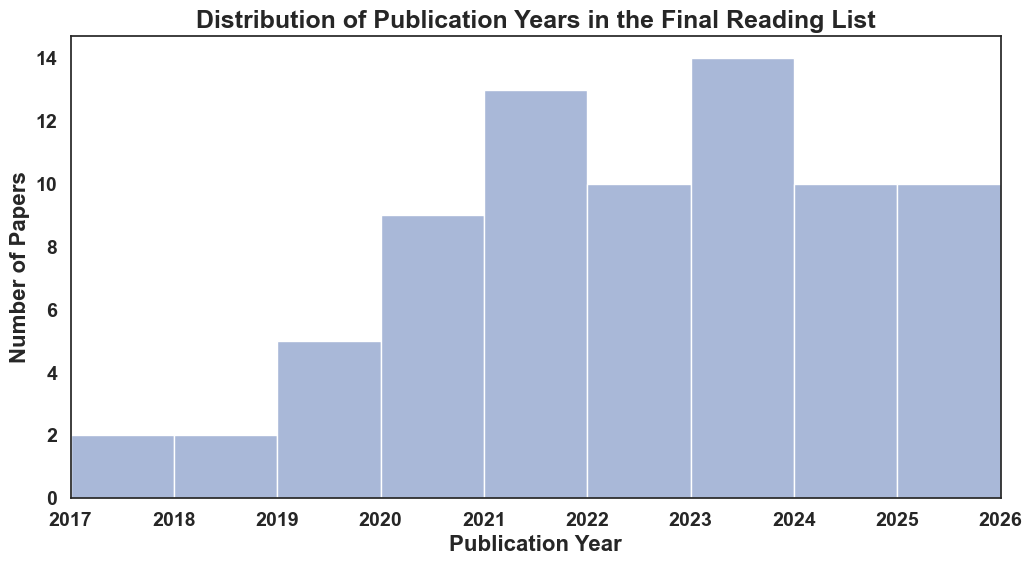

In [5]:
# --- 1. Temporal Distribution Analysis ---
print("--- Analyzing the Temporal Distribution of the Final Reading List ---")
year_distribution = final_list_df['year'].describe()
print(year_distribution)

# Use Set2 color palette
color_palette = sns.color_palette("Set2", 8)
sns.set_palette(color_palette)

# It creates a histogram to visualize the publication years.
plt.figure(figsize=(12, 6))
sns.histplot(data=final_list_df, x='year', bins=range(int(final_list_df['year'].min()), int(final_list_df['year'].max()) + 2), color=color_palette[2])
plt.title('Distribution of Publication Years in the Final Reading List', fontsize=18, fontweight='bold')
plt.xlabel('Publication Year', fontsize=16, fontweight='bold')
plt.ylabel('Number of Papers', fontsize=16, fontweight='bold')
plt.xlim(final_list_df['year'].min(), final_list_df['year'].max() + 1)
# Make tick labels bold
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
plt.show()


--- Visualizing the Methodological Distribution ---


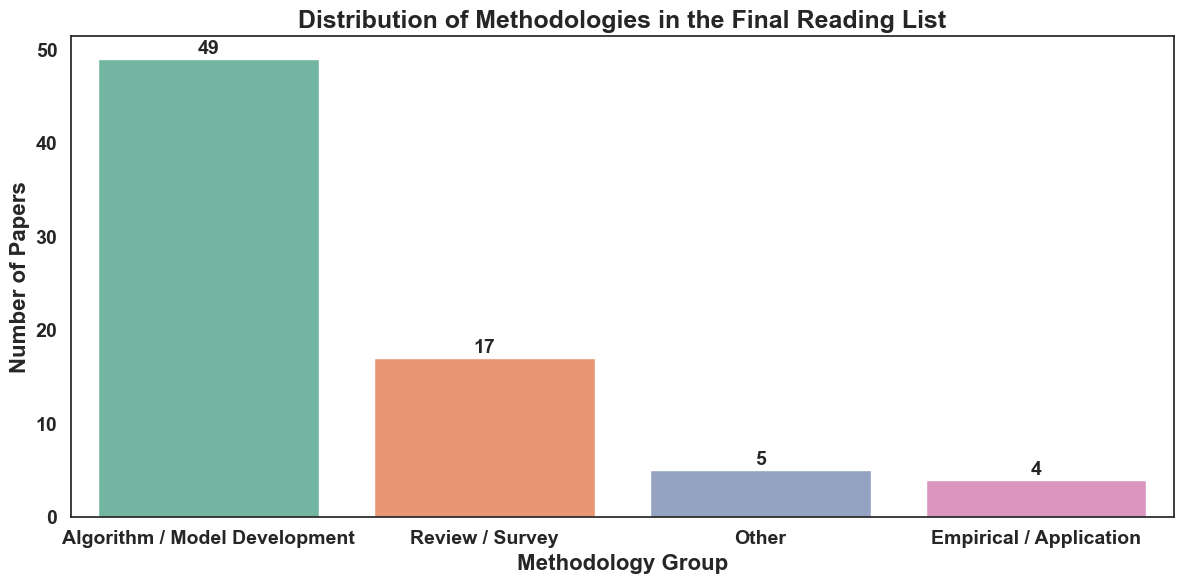

In [6]:
# --- 2. Methodology Distribution Visualization ---
print("\n--- Visualizing the Methodological Distribution ---")
methodology_distribution = final_list_df['methodology_group'].value_counts()

# Use Set2 color palette for consistency
color_palette = sns.color_palette("Set2", 8)
sns.set_palette(color_palette)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=methodology_distribution.index, y=methodology_distribution.values, 
                hue=methodology_distribution.index, palette=color_palette[:len(methodology_distribution)], legend=False)
plt.title('Distribution of Methodologies in the Final Reading List', fontsize=18, fontweight='bold')
plt.xlabel('Methodology Group', fontsize=16, fontweight='bold')
plt.ylabel('Number of Papers', fontsize=16, fontweight='bold')

# Add value labels on top of each bar
for i, v in enumerate(methodology_distribution.values):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=14, fontweight='bold')

# Make tick labels bold
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

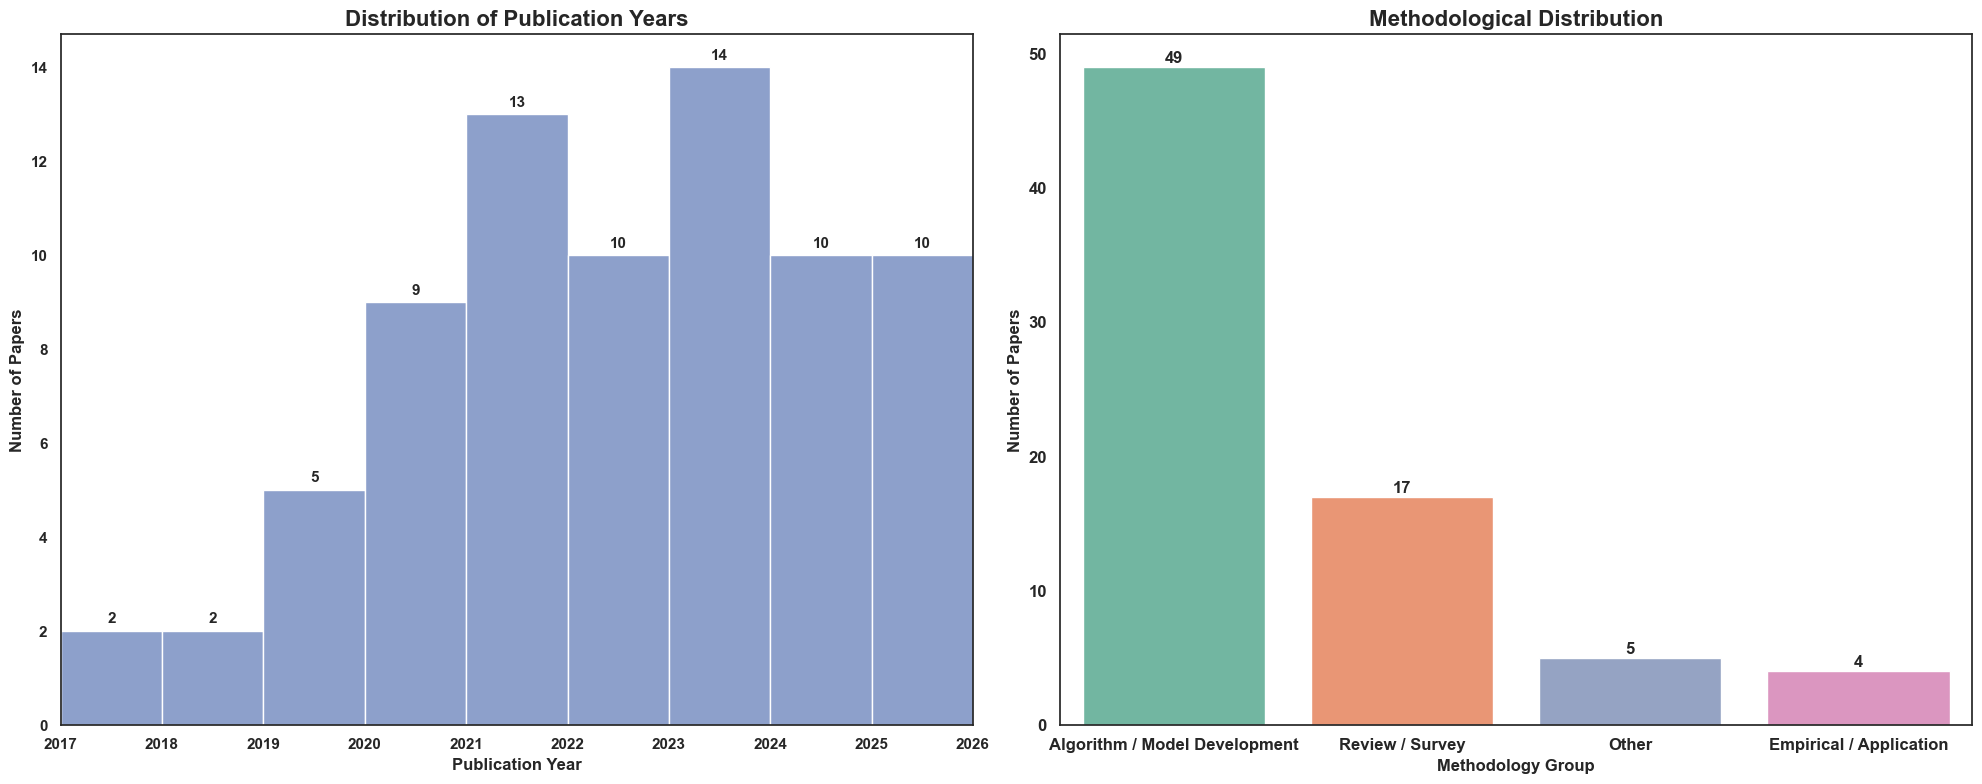

In [12]:
# Side-by-side display of the two plots (temporal distribution and methodology distribution)
sns.set_theme(style="white")
color_palette = sns.color_palette("Set2", 8)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Left: Temporal Distribution (Histogram) ---
min_year = int(final_list_df['year'].min())
max_year = int(final_list_df['year'].max())
bins = range(min_year, max_year + 2)

# Create histogram and store the result to get bar heights
n, bins_edges, patches = axes[0].hist(final_list_df['year'], bins=bins, color=color_palette[2])
axes[0].set_title('Distribution of Publication Years', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Publication Year', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Papers', fontsize=12, fontweight='bold')
axes[0].set_xlim(min_year, max_year + 1)
axes[0].tick_params(axis='x', labelrotation=0, labelsize=11)
axes[0].tick_params(axis='y', labelsize=11)

# Add value labels on top of each bar in the histogram
for i, count in enumerate(n):
    if count > 0:  # Only add label if there are papers in that year
        # Calculate the center of each bin
        bin_center = (bins_edges[i] + bins_edges[i+1]) / 2
        axes[0].text(bin_center, count + 0.1, str(int(count)), ha='center', va='bottom', 
                    fontsize=11, fontweight='bold')

# Make tick labels bold for left plot
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')

# --- Right: Methodology Distribution (Barplot) ---
methodology_distribution = final_list_df['methodology_group'].value_counts()
sns.barplot(x=methodology_distribution.index, y=methodology_distribution.values,
            hue=methodology_distribution.index, palette=color_palette[:len(methodology_distribution)], 
            ax=axes[1], legend=False)
axes[1].set_title('Methodological Distribution', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Methodology Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Papers', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)
# Make tick labels bold for right plot
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')

# Add value labels on top of each bar
for i, v in enumerate(methodology_distribution.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()